In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("student_performance_dataset.csv").drop_duplicates().reset_index(drop=True)
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


**Data Understanding**

In [4]:
df.shape

(500, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  500 non-null    str    
 1   Gender                      500 non-null    str    
 2   Study_Hours_per_Week        500 non-null    int64  
 3   Attendance_Rate             500 non-null    float64
 4   Past_Exam_Scores            500 non-null    int64  
 5   Parental_Education_Level    500 non-null    str    
 6   Internet_Access_at_Home     500 non-null    str    
 7   Extracurricular_Activities  500 non-null    str    
 8   Final_Exam_Score            500 non-null    int64  
 9   Pass_Fail                   500 non-null    str    
dtypes: float64(1), int64(3), str(6)
memory usage: 52.1 KB


In [6]:
df.describe()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,500.000000,500.000000,500.000000,500.000000
mean,25.184000,75.830689,75.218000,56.378000
std,8.804384,13.969186,14.442841,6.266551
min,10.000000,50.116970,50.000000,50.000000
25%,18.000000,64.959340,62.000000,50.000000
50%,26.000000,76.752661,75.500000,55.000000
75%,33.000000,87.548861,88.000000,61.000000
max,39.000000,99.967675,100.000000,77.000000


In [7]:
df.describe(include="object")

C:\Users\hardi_cezwich\AppData\Local\Temp\ipykernel_1236\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Student_ID,Gender,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Pass_Fail
count,500,500,500,500,500,500
unique,500,2,4,2,2,2
top,S147,Female,High School,No,No,Fail
freq,1,256,135,263,268,354


**Data Cleaning**

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Student_ID"].duplicated().sum()

np.int64(0)

In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

Student_ID
<ArrowStringArray>
['S147', 'S136', 'S209', 'S458', 'S078', 'S417', 'S302', 'S009', 'S044',
 'S331',
 ...
 'S109', 'S407', 'S472', 'S442', 'S149', 'S118', 'S358', 'S492', 'S473',
 'S046']
Length: 500, dtype: str

Gender
<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

Study_Hours_per_Week
[31 16 21 27 37 30 24 34 35 11 25 18 12 32 39 14 36 20 26 38 15 28 29 13
 23 22 19 33 10 17]

Attendance_Rate
[68.26784098 78.22292713 87.52509624 92.07648302 98.65551746 84.15919282
 89.38949444 50.68359824 80.8631856  65.49684631 69.83246865 92.10457075
 78.8815977  66.60732063 62.21765777 55.03973015 93.03160089 71.08519673
 97.70434683 85.19730676 80.09676978 97.22048628 93.82220379 89.07572409
 70.01502445 99.02884001 78.98249672 68.89252746 79.25747662 50.91212407
 78.79992089 77.83607924 96.20208796 59.22314357 93.053401   68.86429826
 84.35827527 90.26574837 73.71186544 88.44588707 81.96806785 65.80982911
 86.60922892 70.31961541 60.08652312 66.6407893  85.92286354 76.48

**EDA**

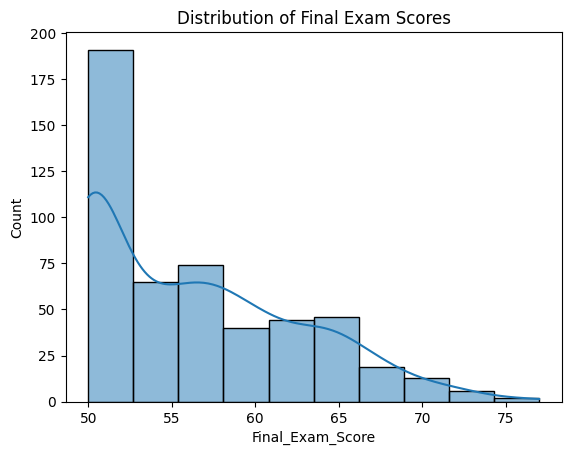

In [ ]:
sns.histplot(df["Final_Exam_Score"], kde=True)
plt.title("Distribution of Final Exam Scores")
plt.show()

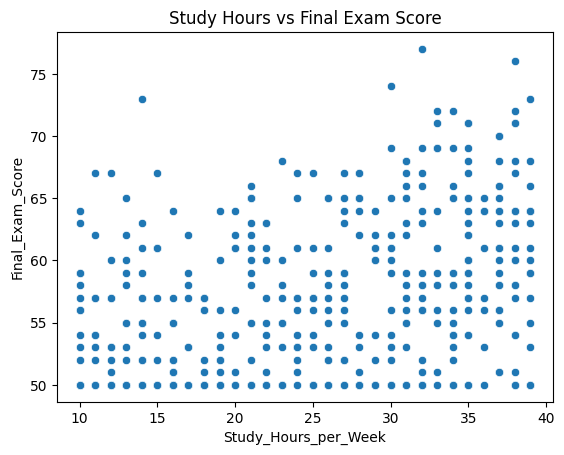

In [12]:
sns.scatterplot(
    data=df,
    x="Study_Hours_per_Week",
    y="Final_Exam_Score"
)

plt.title("Study Hours vs Final Exam Score")
plt.show()

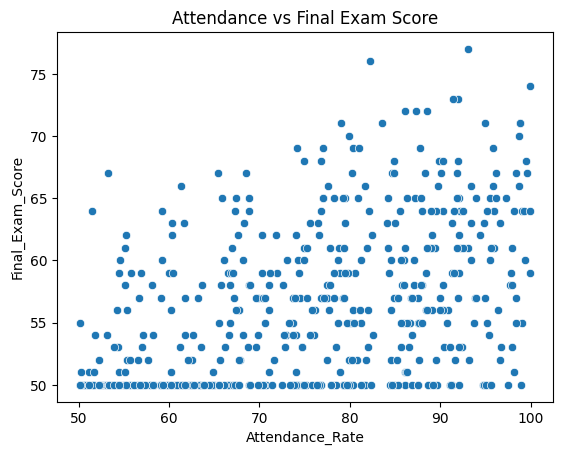

In [13]:
sns.scatterplot(
    data=df,
    x="Attendance_Rate",
    y="Final_Exam_Score"
)

plt.title("Attendance vs Final Exam Score")
plt.show()

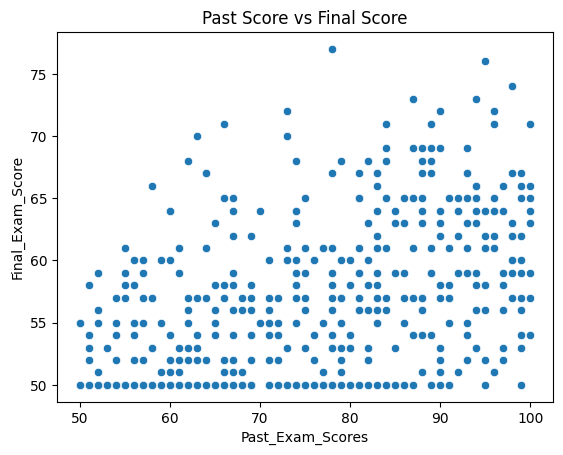

In [14]:
sns.scatterplot(
    data=df,
    x="Past_Exam_Scores",
    y="Final_Exam_Score"
)

plt.title("Past Score vs Final Score")
plt.show()

**Build the Regression Mode**

In [15]:
X = df.drop(columns=["Final_Exam_Score", "Pass_Fail", "Student_ID"])

y = df["Final_Exam_Score"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
numeric_features = [
    "Study_Hours_per_Week",
    "Attendance_Rate",
    "Past_Exam_Scores"
]

In [18]:
categorical_features = [
    "Gender",
    "Parental_Education_Level",
    "Internet_Access_at_Home",
    "Extracurricular_Activities"
]

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

**Linear Regression Model**

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [21]:
y_linear_pred = linear_model.predict(X_test)

**Evaluation Of Linear Model**

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_linear_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_linear_pred)
)

r2 = r2_score(y_test, y_linear_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 3.066883943032393
RMSE: 3.803851087538696
R2: 0.5625390591200365


**Decision Tree Regressor Model**

In [23]:
from sklearn.tree import DecisionTreeRegressor

Decision_Tree = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor())
])

Decision_Tree.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [24]:
y_decision_pred = Decision_Tree.predict(X_test)

**Evaluation Of Tree Model**

In [25]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_decision_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_decision_pred)
)

r2 = r2_score(y_test, y_decision_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 4.39
RMSE: 6.261788881781308
R2: -0.18546602329209438


**Random Forest Model**

In [26]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [27]:
y_forest_pred = random_forest_model.predict(X_test)

**Evaluation Of Forest Model**

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_forest_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_forest_pred)
)

r2 = r2_score(y_test, y_forest_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 3.301100000000001
RMSE: 4.330427577041325
R2: 0.4330381610613261


**Gradient Boosting Regressor**

In [29]:
from sklearn.linear_model import SGDRegressor
SGDRegressor_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SGDRegressor())
])

SGDRegressor_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [30]:
y_descent_pred = SGDRegressor_model.predict(X_test)

**Evaluation Of Gradient Descent Model**

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_descent_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_descent_pred)
)

r2 = r2_score(y_test, y_descent_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 6348723919149.58
RMSE: 6441714096969.133
R2: -1.2545707563004404e+24


**XG Boost Model**

In [32]:
from xgboost import XGBRegressor
XGBRegressor_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor())
])

XGBRegressor_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [33]:
y_boost_pred = XGBRegressor_model.predict(X_test)

**Evaluation Of Boost Model**

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_boost_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_boost_pred)
)

r2 = r2_score(y_test, y_boost_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 3.804455041885376
RMSE: 5.166158507594007
R2: 0.19308513402938843


**Model Dictionary**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42
    )
}

**Model Pipelining**

In [36]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

**Training All Models**

In [37]:
for name, pipeline in pipelines.items():

    pipeline.fit(X_train, y_train)

    print(name, "trained successfully")

Linear Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully
Gradient Boosting trained successfully
XGBoost trained successfully


**Testing Models**

In [38]:
predictions = {}

for name, pipeline in pipelines.items():

    predictions[name] = pipeline.predict(X_test)

**Results Of Testing Model**

In [39]:
results = []

for name, y_pred in predictions.items():

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

print(results_df)

               Model       MAE      RMSE        R2
0  Linear Regression  3.066884  3.803851  0.562539
1      Decision Tree  4.760000  6.534524 -0.290982
2      Random Forest  3.297200  4.373205  0.421781
3  Gradient Boosting  3.235828  4.387396  0.418023
4            XGBoost  3.804455  5.166159  0.193085


**Visualization Of Model Comparison** 

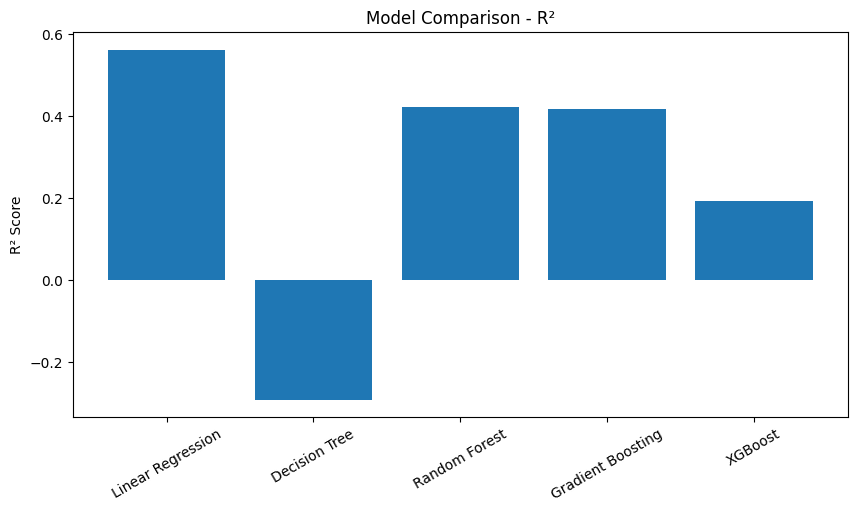

In [40]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["R2"]
)

plt.xticks(rotation=30)
plt.ylabel("R² Score")
plt.title("Model Comparison - R²")

plt.show()

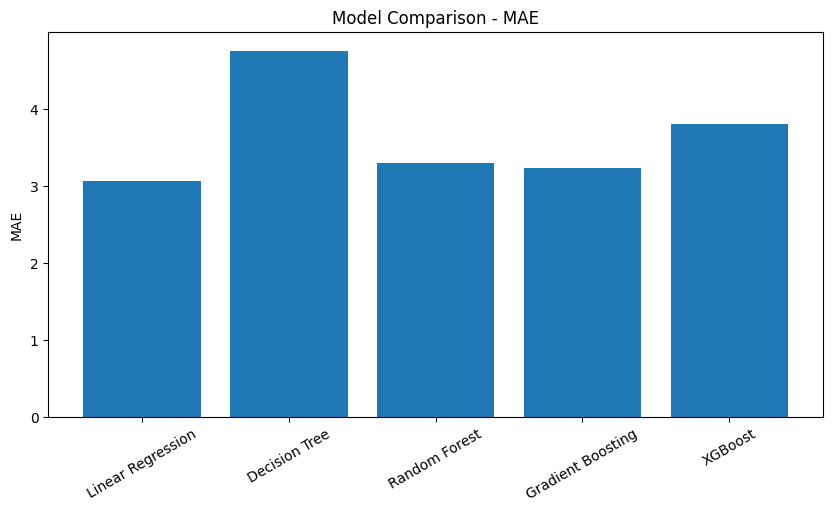

In [41]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.xticks(rotation=30)
plt.ylabel("MAE")
plt.title("Model Comparison - MAE")

plt.show()

**Classification**

In [42]:
X = df.drop(
    columns=[
        "Student_ID",
        "Final_Exam_Score",
        "Pass_Fail"
    ]
)

y = df["Pass_Fail"]

In [43]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns)

print("\nTarget:")
print(y.value_counts())

X shape: (500, 7)
y shape: (500,)

Features:
Index(['Gender', 'Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores',
       'Parental_Education_Level', 'Internet_Access_at_Home',
       'Extracurricular_Activities'],
      dtype='str')

Target:
Pass_Fail
Fail    354
Pass    146
Name: count, dtype: int64


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Preprocessing**

In [45]:
numeric_features = [
    "Study_Hours_per_Week",
    "Attendance_Rate",
    "Past_Exam_Scores"
]

categorical_features = [
    "Gender",
    "Parental_Education_Level",
    "Internet_Access_at_Home",
    "Extracurricular_Activities"
]

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [49]:
y = y.map({
    "Fail": 0,
    "Pass": 1
})

print(y.value_counts())

Pass_Fail
0    354
1    146
Name: count, dtype: int64


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [51]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

In [52]:
for name, pipeline in pipelines.items():

    pipeline.fit(X_train, y_train)

    print(f"{name} trained successfully")

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully
Gradient Boosting trained successfully
XGBoost trained successfully


In [53]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [54]:
from sklearn.pipeline import Pipeline

pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

In [55]:
for name, pipeline in pipelines.items():
    print(name)

Logistic Regression
Decision Tree
Random Forest
Gradient Boosting
XGBoost


In [56]:
pipelines["Random Forest"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [57]:
y_encoded = y.map({
    "Fail": 0,
    "Pass": 1
})

print(y_encoded.value_counts())

Series([], Name: count, dtype: int64)


In [58]:
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    print(f"{name} trained successfully")

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully
Gradient Boosting trained successfully
XGBoost trained successfully


In [59]:
X_test

,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities
433,Male,12,93.175907,66,PhD,No,No
499,Female,22,80.404392,93,Bachelors,Yes,No
488,Female,14,85.361505,86,High School,Yes,No
143,Male,30,56.613811,64,High School,No,No
138,Male,26,95.937526,75,Masters,No,No
...,...,...,...,...,...,...,...
333,Female,34,79.752449,93,Masters,No,No
267,Male,32,85.547624,97,Bachelors,No,Yes
248,Male,21,71.859670,98,High School,Yes,No
331,Female,22,82.333246,57,Masters,No,No


In [60]:
predictions = {}

for name, pipeline in pipelines.items():

    predictions[name] = pipeline.predict(X_test)

In [61]:
predictions["Random Forest"][:10]

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [62]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions["Random Forest"]
})

comparison.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,1,0
5,0,0
6,1,1
7,0,0
8,0,0
9,0,0


In [63]:
from sklearn.metrics import accuracy_score

In [64]:
for name, y_pred in predictions.items():

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    print(name, ":", accuracy)

Logistic Regression : 0.76
Decision Tree : 0.7
Random Forest : 0.77
Gradient Boosting : 0.78
XGBoost : 0.76


In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, y_pred in predictions.items():

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        pos_label=1
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label=1
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label=1
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

classification_results = pd.DataFrame(results)

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.76,0.580645,0.620690,0.600000
1,Decision Tree,0.70,0.481481,0.448276,0.464286
2,Random Forest,0.77,0.636364,0.482759,0.549020
3,Gradient Boosting,0.78,0.606061,0.689655,0.645161
4,XGBoost,0.76,0.580645,0.620690,0.600000


In [67]:
y = y.map({
    "Fail": 0,
    "Pass": 1
})

In [68]:
pos_label=1

In [69]:
precision = precision_score(
    y_test,
    y_pred,
    pos_label=1
)

In [70]:
recall = recall_score(
    y_test,
    y_pred,
    pos_label=1
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=1
)

In [71]:
y = y.map({
    "Fail": 0,
    "Pass": 1
})

In [72]:
classification_results = pd.DataFrame(results)

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.76,0.580645,0.620690,0.600000
1,Decision Tree,0.70,0.481481,0.448276,0.464286
2,Random Forest,0.77,0.636364,0.482759,0.549020
3,Gradient Boosting,0.78,0.606061,0.689655,0.645161
4,XGBoost,0.76,0.580645,0.620690,0.600000


In [73]:
classification_results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,Gradient Boosting,0.78,0.606061,0.689655,0.645161
0,Logistic Regression,0.76,0.580645,0.620690,0.600000
4,XGBoost,0.76,0.580645,0.620690,0.600000
2,Random Forest,0.77,0.636364,0.482759,0.549020
1,Decision Tree,0.70,0.481481,0.448276,0.464286


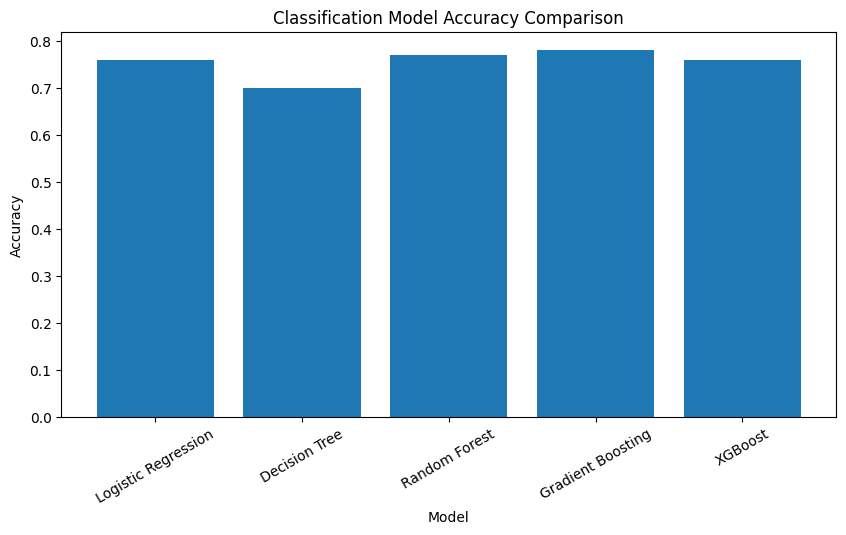

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    classification_results["Model"],
    classification_results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Classification Model Accuracy Comparison")

plt.xticks(rotation=30)

plt.show()

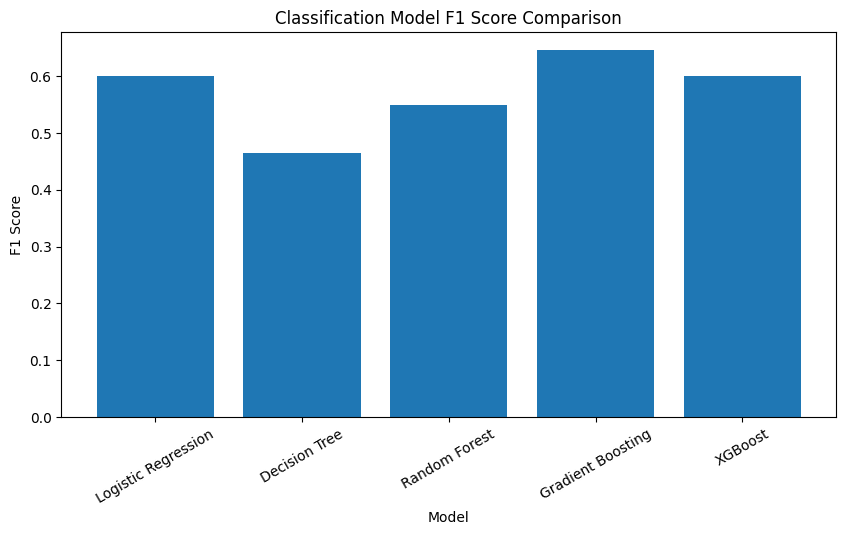

In [75]:
plt.figure(figsize=(10, 5))

plt.bar(
    classification_results["Model"],
    classification_results["F1 Score"]
)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Classification Model F1 Score Comparison")

plt.xticks(rotation=30)

plt.show()

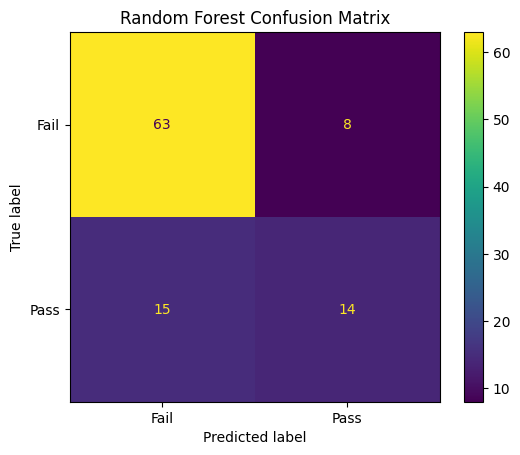

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf_pred = predictions["Random Forest"]

cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=[0, 1]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [77]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions["Random Forest"],
        target_names=["Fail", "Pass"]
    )
)

              precision    recall  f1-score   support

        Fail       0.81      0.89      0.85        71
        Pass       0.64      0.48      0.55        29

    accuracy                           0.77       100
   macro avg       0.72      0.69      0.70       100
weighted avg       0.76      0.77      0.76       100



In [78]:
print("Target values:", y.unique())
print("Target type:", y.dtype)
print("Target contains NaN:", y.isna().sum())

Target values: [nan]
Target type: float64
Target contains NaN: 500


In [79]:
y = y.map({
    "Fail": 0,
    "Pass": 1
})

In [80]:
X = df.drop(columns=[
    "Student_ID",
    "Final_Exam_Score",
    "Pass_Fail"
])

y = df["Pass_Fail"]

print(df["Pass_Fail"].unique())
print(df["Pass_Fail"].value_counts())
print(df["Pass_Fail"].isna().sum())

<ArrowStringArray>
['Pass', 'Fail']
Length: 2, dtype: str
Pass_Fail
Fail    354
Pass    146
Name: count, dtype: int64
0


In [81]:
y = y.map({
    "Fail": 0,
    "Pass": 1
})

In [82]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
for name, pipeline in pipelines.items():
    scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="f1"
)
    cv_results.append({
        "Model": name,
        "Mean F1": scores.mean(),
        "Std F1": scores.std()
    })
cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,Mean F1,Std F1
0,Logistic Regression,0.662919,0.081011
1,Decision Tree,0.560088,0.062373
2,Random Forest,0.592994,0.083203
3,Gradient Boosting,0.642231,0.072464
4,XGBoost,0.609614,0.077473


In [83]:
cv_results_df.sort_values(
    by="Mean F1",
    ascending=False
)

,Model,Mean F1,Std F1
0,Logistic Regression,0.662919,0.081011
3,Gradient Boosting,0.642231,0.072464
4,XGBoost,0.609614,0.077473
2,Random Forest,0.592994,0.083203
1,Decision Tree,0.560088,0.062373


In [84]:
from sklearn.model_selection import RandomizedSearchCV
rf_param_grid = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [None, 8, 12, 16],
    "model__min_samples_split": [2, 4, 8],
    "model__min_samples_leaf": [1, 2, 3],
    "model__max_features": ["sqrt", 0.7, None],
    "model__class_weight": [None, "balanced"]
}

In [85]:
rf_grid = RandomizedSearchCV(
    estimator=pipelines["Random Forest"],
    param_distributions=rf_param_grid,
    n_iter=40,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': [None, 'balanced'], 'model__max_depth': [None, 8, ...], 'model__max_features': ['sqrt', 0.7, ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validat

In [86]:
tuned_rf = rf_grid.best_estimator_

In [87]:
tuned_rf_pred = tuned_rf.predict(X_test)

In [88]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_pred
)

tuned_rf_precision = precision_score(
    y_test,
    tuned_rf_pred,
    pos_label=1
)

tuned_rf_recall = recall_score(
    y_test,
    tuned_rf_pred,
    pos_label=1
)

tuned_rf_f1 = f1_score(
    y_test,
    tuned_rf_pred,
    pos_label=1
)

print("Tuned Random Forest")
print("-------------------")
print("Accuracy :", tuned_rf_accuracy)
print("Precision:", tuned_rf_precision)
print("Recall   :", tuned_rf_recall)
print("F1 Score :", tuned_rf_f1)

Tuned Random Forest
-------------------
Accuracy : 0.76
Precision: 0.5806451612903226
Recall   : 0.6206896551724138
F1 Score : 0.6


In [89]:
original_rf_pred = predictions["Random Forest"]

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    
    "Original Random Forest": [
        accuracy_score(y_test, original_rf_pred),
        precision_score(y_test, original_rf_pred, pos_label=1),
        recall_score(y_test, original_rf_pred, pos_label=1),
        f1_score(y_test, original_rf_pred, pos_label=1)
    ],
    
    "Tuned Random Forest": [
        tuned_rf_accuracy,
        tuned_rf_precision,
        tuned_rf_recall,
        tuned_rf_f1
    ]
})

comparison

,Metric,Original Random Forest,Tuned Random Forest
0,Accuracy,0.770000,0.760000
1,Precision,0.636364,0.580645
2,Recall,0.482759,0.620690
3,F1 Score,0.549020,0.600000


In [90]:
final_model = tuned_rf
final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [91]:
print(final_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Parental_Education_Level',
                                                   'Internet_Access_at_Home',
                                                   'Extracurricular_Activities'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=2, min_samples_split=8,
                                        n_estimators=500, random_state=42))])


In [92]:
import joblib

In [93]:
joblib.dump(
    final_model,
    "student_performance_model.pkl"
)

['student_performance_model.pkl']

In [94]:
loaded_model = joblib.load(
    "student_performance_model.pkl"
)

In [95]:
test_prediction = loaded_model.predict(X_test)
print(test_prediction[:10])

[0 0 0 0 1 0 1 0 0 0]


In [96]:
final_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [97]:
final_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [98]:
rf_model = final_model.named_steps["model"]

print(rf_model)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=8, n_estimators=500, random_state=42)


In [99]:
preprocessor_fitted = final_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

print(feature_names)

['categorical__Gender_Female' 'categorical__Gender_Male'
 'categorical__Parental_Education_Level_Bachelors'
 'categorical__Parental_Education_Level_High School'
 'categorical__Parental_Education_Level_Masters'
 'categorical__Parental_Education_Level_PhD'
 'categorical__Internet_Access_at_Home_No'
 'categorical__Internet_Access_at_Home_Yes'
 'categorical__Extracurricular_Activities_No'
 'categorical__Extracurricular_Activities_Yes'
 'remainder__Study_Hours_per_Week' 'remainder__Attendance_Rate'
 'remainder__Past_Exam_Scores']


In [ ]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
12,remainder__Past_Exam_Scores,0.324708
11,remainder__Attendance_Rate,0.299947
10,remainder__Study_Hours_per_Week,0.219199
5,categorical__Parental_Education_Level_PhD,0.018329
8,categorical__Extracurricular_Activities_No,0.017764
4,categorical__Parental_Education_Level_Masters,0.017032
9,categorical__Extracurricular_Activities_Yes,0.016568
6,categorical__Internet_Access_at_Home_No,0.015586
3,categorical__Parental_Education_Level_High School,0.015237
7,categorical__Internet_Access_at_Home_Yes,0.014399


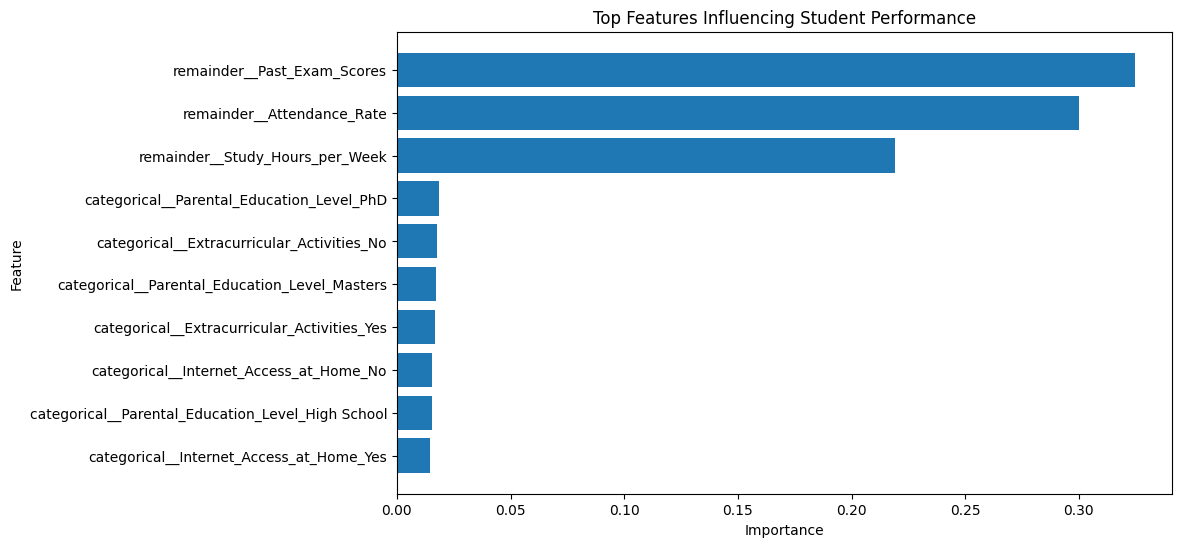

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features Influencing Student Performance")

plt.gca().invert_yaxis()

plt.show()

In [102]:
def predict_student(student_data):

    prediction = final_model.predict(student_data)[0]

    probability = final_model.predict_proba(student_data)[0]
    class_positions = {label: index for index, label in enumerate(final_model.classes_)}

    fail_probability = probability[class_positions[0]]
    pass_probability = probability[class_positions[1]]

    if prediction == 1:
        result = "Pass"
    else:
        result = "Fail"

    return {
        "prediction": result,
        "fail_probability": fail_probability,
        "pass_probability": pass_probability
    }

In [103]:
print(X.columns.tolist())

['Gender', 'Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores', 'Parental_Education_Level', 'Internet_Access_at_Home', 'Extracurricular_Activities']


In [104]:
student = pd.DataFrame([{
    "Gender": "Male",
    "Parental_Education_Level": "Graduate",
    "Internet_Access_at_Home": "Yes",
    "Extracurricular_Activities": "Yes",
    "Study_Hours_per_Week": 10,
    "Attendance_Rate": 85,
    "Past_Exam_Scores": 70
}])

In [105]:
result = predict_student(student)

print(result)

{'prediction': 'Fail', 'fail_probability': np.float64(0.8323806124097923), 'pass_probability': np.float64(0.1676193875902076)}


In [106]:
fail_probability = result["fail_probability"]

if fail_probability >= 0.70:
    risk_level = "High"
elif fail_probability >= 0.40:
    risk_level = "Medium"
else:
    risk_level = "Low"

print("Prediction:", result["prediction"])
print("Fail Probability:", fail_probability)
print("Risk Level:", risk_level)

Prediction: Fail
Fail Probability: 0.8323806124097923
Risk Level: High


In [107]:
feature_importance.head(10)

,Feature,Importance
12,remainder__Past_Exam_Scores,0.324708
11,remainder__Attendance_Rate,0.299947
10,remainder__Study_Hours_per_Week,0.219199
5,categorical__Parental_Education_Level_PhD,0.018329
8,categorical__Extracurricular_Activities_No,0.017764
4,categorical__Parental_Education_Level_Masters,0.017032
9,categorical__Extracurricular_Activities_Yes,0.016568
6,categorical__Internet_Access_at_Home_No,0.015586
3,categorical__Parental_Education_Level_High School,0.015237
7,categorical__Internet_Access_at_Home_Yes,0.014399


In [108]:
rf_model = final_model.named_steps["model"]

preprocessor_fitted = final_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
12,remainder__Past_Exam_Scores,0.324708
11,remainder__Attendance_Rate,0.299947
10,remainder__Study_Hours_per_Week,0.219199
5,categorical__Parental_Education_Level_PhD,0.018329
8,categorical__Extracurricular_Activities_No,0.017764
4,categorical__Parental_Education_Level_Masters,0.017032
9,categorical__Extracurricular_Activities_Yes,0.016568
6,categorical__Internet_Access_at_Home_No,0.015586
3,categorical__Parental_Education_Level_High School,0.015237
7,categorical__Internet_Access_at_Home_Yes,0.014399


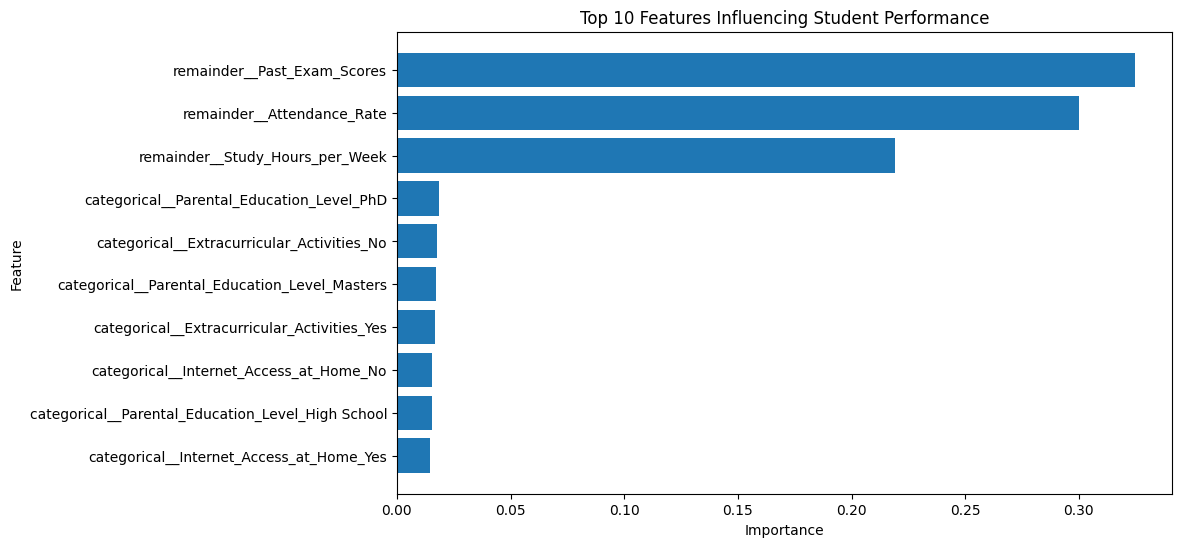

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Student Performance")

plt.gca().invert_yaxis()

plt.show()

In [110]:
top_5_features = feature_importance.head(5)

important_factors = top_5_features["Feature"].tolist()

print("Important factors:")
for factor in important_factors:
    print("-", factor)

Important factors:
- remainder__Past_Exam_Scores
- remainder__Attendance_Rate
- remainder__Study_Hours_per_Week
- categorical__Parental_Education_Level_PhD
- categorical__Extracurricular_Activities_No


In [111]:
clean_factors = []

for factor in important_factors:
    factor = factor.replace("categorical__", "")
    factor = factor.replace("remainder__", "")
    factor = factor.replace("_", " ")
    clean_factors.append(factor)

print(clean_factors)

['Past Exam Scores', 'Attendance Rate', 'Study Hours per Week', 'Parental Education Level PhD', 'Extracurricular Activities No']


In [112]:
student_prediction = result["prediction"]

fail_probability = result["fail_probability"]

pass_probability = result["pass_probability"]

student_information = {
    "prediction": student_prediction,
    "fail_probability": float(fail_probability),
    "pass_probability": float(pass_probability),
    "risk_level": risk_level,
    "important_factors": clean_factors
}

student_information

{'prediction': 'Fail',
 'fail_probability': 0.8323806124097923,
 'pass_probability': 0.1676193875902076,
 'risk_level': 'High',
 'important_factors': ['Past Exam Scores',
  'Attendance Rate',
  'Study Hours per Week',
  'Parental Education Level PhD',
  'Extracurricular Activities No']}

In [113]:
prompt = f"""
You are an AI student performance support assistant.

Analyze the following machine learning prediction.

Prediction: {student_prediction}

Failure probability: {fail_probability:.2%}

Pass probability: {pass_probability:.2%}

Risk level: {risk_level}

Important factors identified by the machine learning model:
{", ".join(clean_factors)}

Provide the following:

1. Explain the prediction in simple language.
2. Explain the important factors.
3. Give 3 practical recommendations for improvement.
4. Create a simple 7-day study plan.
5. Encourage the student positively.

Important:
- Do not say that the prediction is certain.
- Do not invent student information.
- Clearly distinguish the ML prediction from advice.
- Keep the explanation easy for a student to understand.
"""

print(prompt)


You are an AI student performance support assistant.

Analyze the following machine learning prediction.

Prediction: Fail

Failure probability: 83.24%

Pass probability: 16.76%

Risk level: High

Important factors identified by the machine learning model:
Past Exam Scores, Attendance Rate, Study Hours per Week, Parental Education Level PhD, Extracurricular Activities No

Provide the following:

1. Explain the prediction in simple language.
2. Explain the important factors.
3. Give 3 practical recommendations for improvement.
4. Create a simple 7-day study plan.
5. Encourage the student positively.

Important:
- Do not say that the prediction is certain.
- Do not invent student information.
- Clearly distinguish the ML prediction from advice.
- Keep the explanation easy for a student to understand.



In [114]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("MISTRAL_API_KEY")

print("API key loaded:", api_key is not None)

API key loaded: True


In [115]:
import os

print(os.getcwd())

c:\Users\hardi_cezwich\OneDrive\Desktop\IBM Gen Ai\student_performance_predictor


In [116]:
from mistralai.client import Mistral

client = Mistral(api_key=api_key)

print("Mistral client created successfully")

Mistral client created successfully


In [117]:
models = client.models.list()

for model in models.data:
    print(model.id)

codestral-2508
codestral-latest
mistral-code-latest
mistral-code-fim-latest
mistral-small-2603
mistral-small-latest
mistral-vibe-cli-fast
magistral-small-latest
voxtral-small-2507
voxtral-small-latest
labs-leanstral-1-5-1
labs-leanstral-1-5
ministral-3b-2512
ministral-3b-latest
ministral-8b-2512
ministral-8b-latest
ministral-14b-2512
ministral-14b-latest
mistral-medium-latest
mistral-medium
mistral-medium-3-5
mistral-medium-3.5
mistral-medium-3
mistral-medium-2604
mistral-vibe-cli-latest
mistral-vibe-cli-with-tools
magistral-medium-latest
mistral-embed-2312
mistral-embed
codestral-embed
codestral-embed-2505
mistral-moderation-2603
mistral-ocr-2512
mistral-ocr-3-0
mistral-ocr-3
mistral-ocr-4-0
mistral-ocr-latest
mistral-ocr-4
mistral-ocr-4-1
voxtral-mini-2602
voxtral-mini-latest
voxtral-mini-transcribe-realtime-2602
voxtral-mini-realtime-2602
voxtral-mini-realtime-latest
voxtral-mini-tts-2603
voxtral-mini-tts-latest


In [118]:
response = client.chat.complete(
    model="codestral-2508",
    messages=[
        {
            "role": "user",
            "content": "Explain machine learning in one simple sentence."
        }
    ]
)
print(response.choices[0].message.content)

Machine learning is a method where computers learn patterns from data to make predictions or decisions without being explicitly programmed.


In [119]:
prompt = f"""
You are an AI educational support assistant.

A machine learning model analyzed a student's academic information.

Prediction: {result["prediction"]}

Failure Probability: {result["fail_probability"]:.2%}

Pass Probability: {result["pass_probability"]:.2%}

Risk Level: {risk_level}

Important factors identified by the ML model:
{", ".join(clean_factors)}

Please provide:

1. Explain the prediction in simple language.
2. Explain the important factors.
3. Give 3 practical recommendations for the student.
4. Create a simple 7-day study plan.
5. Give encouraging advice.

Important:
- The prediction is an estimate, not a certainty.
- Do not claim that the student will definitely pass or fail.
- Do not invent information about the student.
- Treat the important factors as model-derived signals, not proof of causation.
"""

print(prompt)


You are an AI educational support assistant.

A machine learning model analyzed a student's academic information.

Prediction: Fail

Failure Probability: 83.24%

Pass Probability: 16.76%

Risk Level: High

Important factors identified by the ML model:
Past Exam Scores, Attendance Rate, Study Hours per Week, Parental Education Level PhD, Extracurricular Activities No

Please provide:

1. Explain the prediction in simple language.
2. Explain the important factors.
3. Give 3 practical recommendations for the student.
4. Create a simple 7-day study plan.
5. Give encouraging advice.

Important:
- The prediction is an estimate, not a certainty.
- Do not claim that the student will definitely pass or fail.
- Do not invent information about the student.
- Treat the important factors as model-derived signals, not proof of causation.



In [120]:
response = client.chat.complete(
    model="codestral-2508",
    messages=[
        {
            "role": "system",
            "content": "You are a helpful educational support assistant."
        },
        {
            "role": "user",
            "content": prompt
        }
    ]
)

ai_response = response.choices[0].message.content

print(ai_response)

1. **Explanation of the Prediction:**
The machine learning model has analyzed the student's academic information and predicts that the student has a high probability (83.24%) of failing. This means that based on the data and patterns the model has learned, there's a strong likelihood that the student may not pass. However, it's important to remember that this is an estimate, and the student's actual outcome could be different.

2. **Explanation of Important Factors:**
The model has identified several factors that are contributing to the prediction:
   - **Past Exam Scores:** The student's performance in previous exams is a significant factor. Lower scores in the past may indicate difficulty in understanding or retaining the material.
   - **Attendance Rate:** Regular attendance is crucial for learning. A lower attendance rate might mean the student is missing out on important lessons and information.
   - **Study Hours per Week:** The amount of time the student spends studying each wee

In [121]:
def generate_ai_advice(result, risk_level, clean_factors):
    prompt = f"""
You are an AI educational support assistant.

Machine Learning Prediction:
{result["prediction"]}

Failure Probability:
{result["fail_probability"]:.2%}

Pass Probability:
{result["pass_probability"]:.2%}

Risk Level:
{risk_level}

Important Model Factors:
{", ".join(clean_factors)}

Provide:

1. Prediction explanation
2. Important factors
3. Three recommendations
4. Seven-day study plan
5. Encouraging advice

The prediction is an estimate and not a certainty.
Do not invent student information.
Do not claim that the student will definitely pass or fail.
"""

    response = client.chat.complete(
        model="codestral-2508",
        messages=[
            {
                "role": "system",
                "content": "You are a helpful educational support assistant."
            },
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.choices[0].message.content

In [122]:
ai_advice = generate_ai_advice(
    result,
    risk_level,
    clean_factors
)

print(ai_advice)

### Prediction Explanation

The machine learning model predicts that the student has an 83.24% probability of failing and a 16.76% probability of passing. This high failure probability suggests that the student may face significant challenges in their current academic performance. The model's prediction is based on several factors, including past exam scores, attendance rate, study hours per week, parental education level, and extracurricular activities.

### Important Factors

1. **Past Exam Scores**: The student's historical performance in exams is a critical factor. Lower past exam scores indicate a higher likelihood of failure.
2. **Attendance Rate**: Regular attendance is crucial for academic success. A low attendance rate can significantly impact the student's ability to keep up with the course material.
3. **Study Hours per Week**: Insufficient study hours can lead to poor understanding and retention of the material. The model suggests that the student may not be dedicating enou

In [123]:
import joblib

joblib.dump(
    final_model,
    "student_performance_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
